# Open-Source Computer Use Agent

## Concept
An AI agent that operates a computer like a human - using mouse and keyboard based on natural
language commands. It continuously analyzes screen content and executes appropriate UI actions.


## Technical Stack
- **E2B Desktop Sandbox**: Secure Ubuntu environment
- **Groq API (Llama-3.2-90B)**: Vision analysis
- **HuggingFace (OS-Atlas-Base-7B)**: UI element detection
- **FFMPEG**: Screen recording
- **Core Libraries**: e2b-code-interpreter, openai, gradio_client, PIL

## Why E2B Desktop Sandbox?
The E2B sandbox provides critical benefits:
1. **Security**: Isolated environment prevents any risk to host system
2. **Performance**: Cloud-based execution with minimal latency
3. **Reproducibility**: Clean Ubuntu environment for consistent behavior
4. **Built-in Tools**: Pre-configured with necessary utilities (xdotool, scrot)
5. **API-first**: Simple programmatic control of the desktop environment


## Architecture Overview
The system follows a continuous loop:
1. Capture screenshot of current state
2. Analyze using Vision LLM to determine next action
3. If UI interaction needed:
   - Use OS-Atlas to detect precise UI elements
   - Execute action via mouse/keyboard
4. Record all actions for verification
5. Repeat until task complete

This implementation focuses on being:
- Open Source: Using only open-weight models
- Modular: Easy to swap components
- Secure: Isolated execution environment
- Extensible: Simple to add new capabilities

# Flow Chart
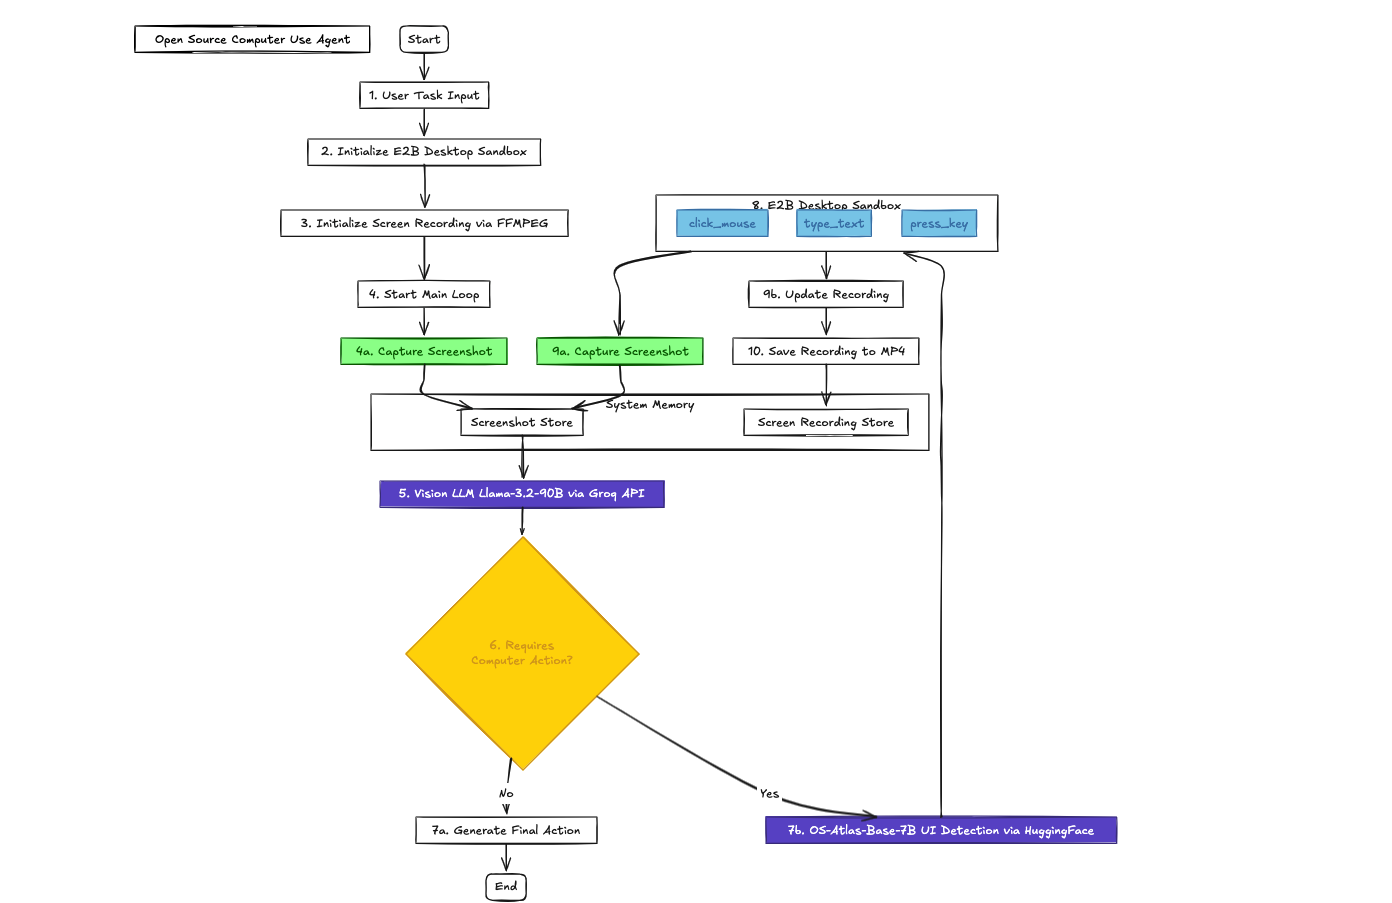

# Initial Setup and Imports


In [ ]:
!pip install e2b-code-interpreter gradio_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.8/321.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 3.7 MB/s eta 0:00:00


# Import necessary libraries

In [ ]:
import base64
import json
import time
import re
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display
from openai import OpenAI
from gradio_client import Client
from google.colab import userdata
from e2b_code_interpreter import Sandbox

# LLM Configuration

In [ ]:
# Initialize OpenAI client with Groq's API endpoint
client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=userdata.get("GROQ_API_KEY")
)

# Tool Definitions

In [165]:
# # Defining available tools for the LLM to interact with the agent
tools = [
{
        # Tool for mouse clicking operations
        "type": "function",
        "function": {
            "name": "click_mouse",
            "description": "Click at a specific UI element or location on the screen",
            "parameters": {
                "type": "object",
                "properties": {
                    "location": {
                        "type": "string",
                        "description": "Description of UI element to click (e.g., 'web browser icon', 'Firefox icon', 'YouTube search bar', etc.)",
                    }
                },
                "required": ["location"]
            }
        }
    },
     # Tool for typing text
    {
        "type": "function",
        "function": {
            "name": "type_text",
            "description": "Type text using the keyboard",
            "parameters": {
                "type": "object",
                "properties": {
                    "text": {
                        "type": "string",
                        "description": "The text to type"
                    }
                },
                "required": ["text"]
            }
        }
    },
    # Tool for keyboard key presses
    {
        "type": "function",
        "function": {
            "name": "press_key",
            "description": "Press a keyboard key",
            "parameters": {
                "type": "object",
                "properties": {
                    "key": {
                        "type": "string",
                        "description": "The key to press (e.g., Return, Tab)"
                    }
                },
                "required": ["key"]
            }
        }
    }
]


# Screenshot Management

In [ ]:
# Functions to capture and display screenshots

def capture_screenshot(sbx):
    """Capture a full screenshot (including the pointer) and return raw bytes."""
    screenshot_path = "screenshot.png"
    sbx.commands.run(f"scrot --pointer {screenshot_path}")
    screenshot_bytes = sbx.files.read(screenshot_path, format="bytes")
    sbx.files.remove(screenshot_path)
    return screenshot_bytes

def display_screenshot(screenshot_bytes):
    """Resize screenshot for display, also save screenshot.png for OS-ATLAS."""
    img = PILImage.open(BytesIO(screenshot_bytes))
    w, h = img.size
    small_img = img.resize((w // 2, h // 2))
    display(small_img)
    img.save("screenshot.png")

 # Screen Recording Functions

In [99]:
# Global flag for recording state
recording_active = False

def setup_recording(sbx):
    """Setup ffmpeg recording environment in sandbox"""
    try:
        # Install required packages
        sbx.commands.run("sudo apt-get update")
        sbx.commands.run("sudo apt-get install -y ffmpeg x11-utils xauth")

        # Setup X11 environment
        sbx.commands.run("touch /home/user/.Xauthority")
        sbx.commands.run("xauth generate :1 . trusted")

        # Setup recording directory
        sbx.commands.run("sudo mkdir -p /tmp/recording")
        sbx.commands.run("sudo chmod 777 /tmp/recording")
        print("Recording setup completed")
        return "/tmp/recording/output.mp4"
    except Exception as e:
        print(f"Setup error: {e}")
        return None


def start_recording(sbx):
    """Initialize and start screen recording using ffmpeg"""
    global recording_active
    try:
        # Clear any existing recordings
        sbx.commands.run("sudo rm -rf /tmp/recording")
        sbx.commands.run("sudo mkdir -p /tmp/recording")
        sbx.commands.run("sudo chmod 777 /tmp/recording")

        # Get correct display
        try:
            display = sbx.commands.run("echo $DISPLAY").stdout.strip()
            if not display:
                # Try to find active display
                displays = sbx.commands.run("w -h | grep -o ':[0-9]*'").stdout.strip()
                display = displays.split('\n')[0] if displays else ':1'
        except:
            display = ':1'  # Fallback display

        # Set XAUTHORITY and ensure X access
        sbx.commands.run("export XAUTHORITY=/home/user/.Xauthority")
        sbx.commands.run(f"xhost +local:")

        # Start ffmpeg with correct display
        cmd = f"""DISPLAY={display} XAUTHORITY=/home/user/.Xauthority ffmpeg -f x11grab \
                -video_size 1024x768 -framerate 10 \
                -i {display} -c:v libx264 -preset ultrafast \
                -y /tmp/recording/output.mp4 > /tmp/recording/ffmpeg.log 2>&1 &"""
        print(f"Starting ffmpeg with display {display}...")
        sbx.commands.run(cmd)

        # Give ffmpeg time to start
        time.sleep(3)

        # Verify ffmpeg is running
        try:
            ps_out = sbx.commands.run("ps aux | grep '[f]fmpeg'").stdout  # Use [] to exclude grep itself
            print(f"PS output: {ps_out}")

            log_out = sbx.commands.run("cat /tmp/recording/ffmpeg.log").stdout
            print(f"Log output: {log_out}")

            file_check = sbx.commands.run("ls -l /tmp/recording/").stdout
            print(f"Directory contents: {file_check}")

            if "ffmpeg" in ps_out and "error" not in log_out.lower():
                recording_active = True
                print("Recording started successfully")
            else:
                print("Warning: ffmpeg process verification failed")
                # Additional debug info
                print("\nDisplay environment:")
                print(sbx.commands.run("env | grep DISPLAY").stdout)
                print("\nX server check:")
                print(sbx.commands.run("xdpyinfo || echo 'xdpyinfo failed'").stdout)

        except Exception as e:
            print(f"Verification error: {e}")

    except Exception as e:
        print(f"Recording start error: {e}")

def stop_recording(sbx):
   """Stop recording and save the video file"""
    global recording_active
    try:
        if recording_active:
            # Try multiple ways to ensure ffmpeg is stopped
            try:
                sbx.commands.run("pkill -2 ffmpeg")  # Graceful shutdown
                time.sleep(1)
                # Check if process still exists
                if "ffmpeg" in sbx.commands.run("ps aux").stdout:
                    sbx.commands.run("pkill -9 ffmpeg")  # Force kill if still running
            except Exception as e:
                print(f"FFmpeg stop error: {e}")

            time.sleep(3)  # Give time for file to finish writing

            try:
                # Verify file exists and has content
                file_info = sbx.commands.run("ls -l /tmp/recording/output.mp4").stdout
                print(f"File info: {file_info}")

                # Get video file
                print("Reading video file...")
                video_bytes = sbx.files.read("/tmp/recording/output.mp4", format="bytes")

                print(f"Video size: {len(video_bytes)} bytes")
                if len(video_bytes) > 0:
                    # Save to Colab with explicit path
                    output_path = "/content/screen_recording.mp4"
                    with open(output_path, "wb") as f:
                        f.write(video_bytes)
                    print(f"Saved recording to {output_path}")

                    # Verify file
                    from pathlib import Path
                    if Path(output_path).exists():
                        file_size = Path(output_path).stat().st_size
                        print(f"Video file verified: {file_size} bytes")
                else:
                    print("Warning: Video file is empty")

            except Exception as e:
                print(f"Error saving video: {e}")
                print("Debugging info:")
                try:
                    print("Recording directory contents:")
                    print(sbx.commands.run("ls -la /tmp/recording/").stdout)
                    print("\nFFmpeg processes:")
                    print(sbx.commands.run("ps aux | grep ffmpeg").stdout)
                except Exception as debug_e:
                    print(f"Debug info error: {debug_e}")

            recording_active = False
        else:
            print("No active recording to stop")

    except Exception as e:
        print(f"Recording stop error: {e}")

# Input Handling Functions

In [ ]:
# Functions for system interaction through keyboard and mouse

def type_text(sbx, text):
    """Type text with proper escaping and delay for reliability"""
    escaped_text = text.replace("'", "'\\''")
    sbx.commands.run(f"xdotool type --delay 100 '{escaped_text}'")
    time.sleep(0.5)

def press_key(sbx, key):
    """Execute keyboard key press events"""
    sbx.commands.run(f"xdotool key {key}")
    time.sleep(0.5)

# OS-ATLAS Integration

In [156]:
# Setup and configure OS-ATLAS for UI element detection
from gradio_client import Client, handle_file
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))  # Store your token in Colab userdata

OSATLAS_HUGGINGFACE_SOURCE = "maxiw/OS-ATLAS"
OSATLAS_HUGGINGFACE_MODEL = "OS-Copilot/OS-Atlas-Base-7B"
OSATLAS_HUGGINGFACE_API = "/run_example"

huggingface_client = Client(
    OSATLAS_HUGGINGFACE_SOURCE,
    hf_token=userdata.get("HF_TOKEN")
)

Loaded as API: https://maxiw-os-atlas.hf.space ✔


# Coordinate Detection

In [160]:
"""Use OS-Atlas to locate UI elements in screenshots"""
def get_coordinates(location_query):
    """Retrieve bounding box from OS-Atlas and return midpoint."""
    import re
    try:
        # More specific prompt for UI elements
        prompt = f"Locate the exact position of '{location_query}' in the screenshot. Return only the bounding box coordinates in format: x1 y1 x2 y2"
        print(f"[OS-Atlas] Prompt: {prompt}")

        result = huggingface_client.predict(
            image=handle_file("screenshot.png"),
            text_input=prompt,
            model_id=OSATLAS_HUGGINGFACE_MODEL,
            api_name=OSATLAS_HUGGINGFACE_API,
            fn_index=0  # Explicitly set function index
        )

        # More robust number extraction
        numbers = re.findall(r'-?\d+(?:\.\d+)?', str(result))
        if len(numbers) >= 4:
            x1, y1, x2, y2 = map(float, numbers[:4])
            # Validate coordinates
            if all(0 <= coord <= 2000 for coord in [x1, y1, x2, y2]):  # Reasonable screen size limit
                return int((x1 + x2) / 2), int((y1 + y2) / 2)

        print(f"[OS-Atlas] Invalid coordinates in response: {result}")
        return None, None

    except Exception as e:
        print(f"[OS-Atlas error]: {str(e)}")
        print(f"Request details - Image: screenshot.png, Query: {location_query}")
        print(f"Full response: {result if 'result' in locals() else 'No response'}")
        return None, None

# Sandbox Environment Setup

In [166]:
# Initialize the virtual desktop environment
sbx = Sandbox(
    api_key = userdata.get("E2B_API_KEY"),
    template ="desktop"
) # By default sandbox alive for 5 minutes

# Main Execution Loop

Setup error: Command exited with code 1 and error:
xauth: (argv):1:  unable to open display ":1".

Starting ffmpeg with display :99...
PS output: user        1737 17.0  2.8 422232 115700 ?       SLl  23:10   0:00 ffmpeg -f x11grab -video_size 1024x768 -framerate 10 -i :99 -c:v libx264 -preset ultrafast -y /tmp/recording/output.mp4

Log output: ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3la

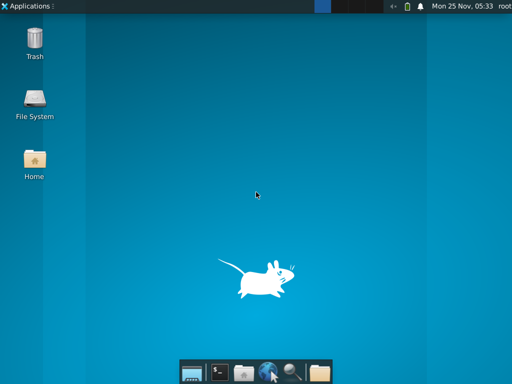


LLM Response: None

Tool Calls: [ChatCompletionMessageToolCall(id='call_t9tz', function=Function(arguments='{"location":"web browser icon on the taskbar or dock"}', name='click_mouse'), type='function'), ChatCompletionMessageToolCall(id='call_1sdw', function=Function(arguments='{"location":"YouTube search bar"}', name='click_mouse'), type='function'), ChatCompletionMessageToolCall(id='call_a2dk', function=Function(arguments='{"text":"Cold play latest music video"}', name='type_text'), type='function'), ChatCompletionMessageToolCall(id='call_ft40', function=Function(arguments='{"key":"Return"}', name='press_key'), type='function'), ChatCompletionMessageToolCall(id='call_5b70', function=Function(arguments='{"location":"first video result after Cold play latest music video search"}', name='click_mouse'), type='function')]
Clicking on "web browser icon on the taskbar or dock"...
[OS-Atlas] Prompt: Locate the exact position of 'web browser icon on the taskbar or dock' in the screenshot. Re

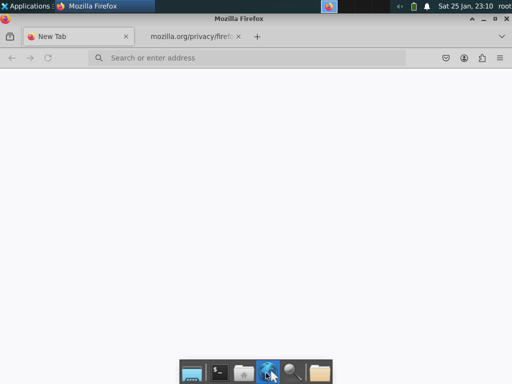

Clicking on "YouTube search bar"...
[OS-Atlas] Prompt: Locate the exact position of 'YouTube search bar' in the screenshot. Return only the bounding box coordinates in format: x1 y1 x2 y2
Clicked on "YouTube search bar" at coordinates 492, 118.


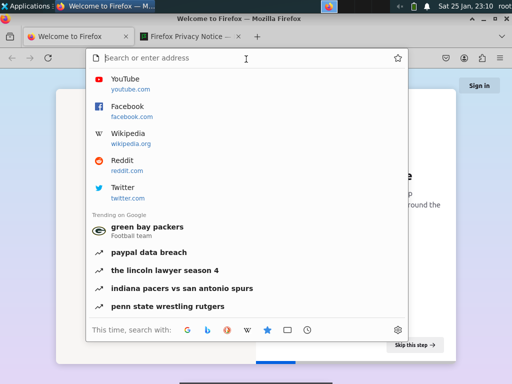

Typing text: "Cold play latest music video"


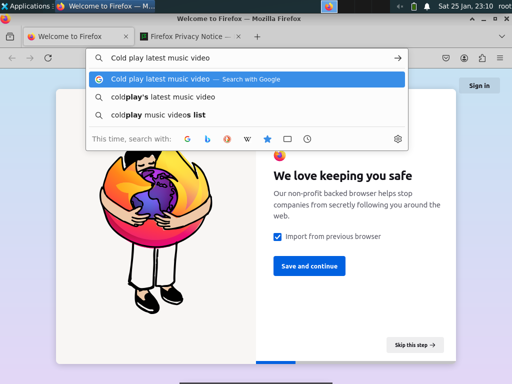

Pressing key: "Return"


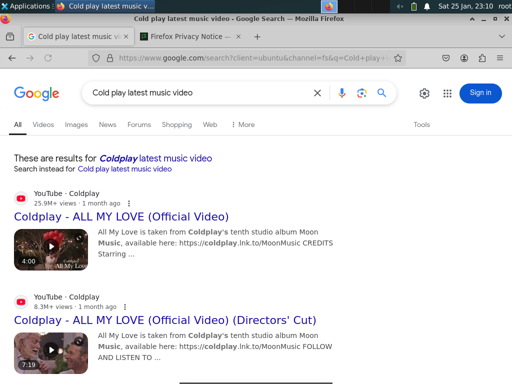

Clicking on "first video result after Cold play latest music video search"...
[OS-Atlas] Prompt: Locate the exact position of 'first video result after Cold play latest music video search' in the screenshot. Return only the bounding box coordinates in format: x1 y1 x2 y2
Clicked on "first video result after Cold play latest music video search" at coordinates 243, 433.


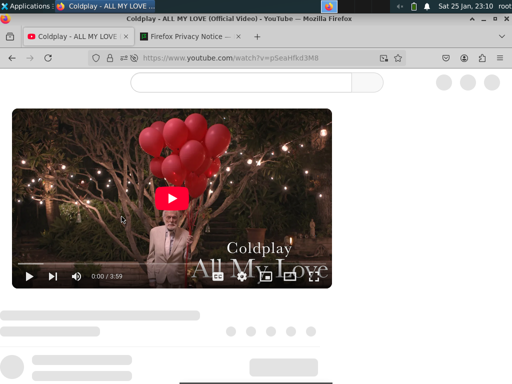

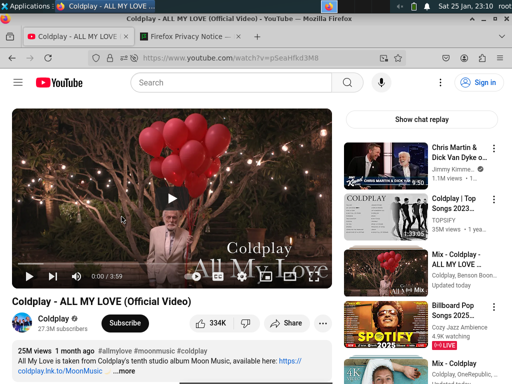


LLM Response: Function calling is not allowed in this dialogue.

Tool Calls: None
No tool calls. Ending loop.
File info: -rw-r--r-- 1 user user 1456860 Jan 25 23:11 /tmp/recording/output.mp4

Reading video file...
Video size: 1456860 bytes
Saved recording to /content/screen_recording.mp4
Video file verified: 1456860 bytes
Recording finished


In [167]:
# Setup recording and execute the automation sequence
video_path = setup_recording(sbx)
start_recording(sbx)

try:
    while True:
        # Main automation loop with screenshot capture, LLM interaction, and tool execution
        # 1) Capture and display the initial screenshot
        time.sleep(1)  # Wait for screen to settle
        screenshot = capture_screenshot(sbx)
        display_screenshot(screenshot)
        base64_screenshot = base64.b64encode(screenshot).decode("utf-8")

        # 2) Ask the LLM
        completion = client.chat.completions.create(
            model="llama-3.2-90b-vision-preview",
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_screenshot}"}},
                        {"type": "text", "text": "Analyze the screen contents."},
                        {"type": "text", "text": "Objective: Open web browser, go to YouTube, search for 'Cold play latest music video', and click the first video"},
                        {"type": "text", "text": "Once the video starts playing, terminate the operation without further actions."}
                    ]
                }
            ],
            tools=tools
        )
        llm_text = completion.choices[0].message.content
        print("\nLLM Response:", llm_text)
        tool_calls = completion.choices[0].message.tool_calls
        print("\nTool Calls:", tool_calls)

        if not tool_calls:
            print("No tool calls. Ending loop.")
            break

        for tool_call in tool_calls:
            fn_name = tool_call.function.name
            args = json.loads(tool_call.function.arguments)

            if fn_name == "click_mouse":
                location = args["location"]
                print(f'Clicking on "{location}"...')
                x, y = get_coordinates(location)
                if x is not None and y is not None:
                    sbx.commands.run(f"xdotool mousemove --sync {x} {y}")
                    time.sleep(0.5)  # Wait for mouse movement
                    sbx.commands.run("xdotool click 1")
                    print(f'Clicked on "{location}" at coordinates {x}, {y}.')

                    # Wait for click action to complete and page to start loading
                    time.sleep(2)

                    # Wait for page load or UI update
                    time.sleep(3)

                    # Capture the result
                    screenshot = capture_screenshot(sbx)
                    display_screenshot(screenshot)
                else:
                    print(f"Could not find coordinates for '{location}'. Skipping click.")

            elif fn_name == "type_text":
                text = args["text"]
                print(f'Typing text: "{text}"')
                type_text(sbx, text)

                # Wait for typing to complete
                time.sleep(1)

                # Capture the result
                screenshot = capture_screenshot(sbx)
                display_screenshot(screenshot)

            elif fn_name == "press_key":
                key = args["key"]
                print(f'Pressing key: "{key}"')
                press_key(sbx, key)

                # Wait for key press action and potential page load
                if key.lower() in ["return", "enter"]:
                    time.sleep(4)  # Longer wait for page load
                else:
                    time.sleep(1)  # Normal wait for UI update

                # Capture the result
                screenshot = capture_screenshot(sbx)
                display_screenshot(screenshot)

            # Additional wait after any action to ensure UI is stable
            time.sleep(1)

        # Wait before next iteration to ensure stable state
        time.sleep(2)

finally:
    # Cleanup and finalize recording
    if recording_active:
        time.sleep(2)  # Final wait to capture last action
        stop_recording(sbx)
    print('Recording finished')